## _Neural Data Science Project SoSe2026_ — Parameter inference with Jaxley

**Lecturer**: Prof. Dr. Philipp Berens, Dr. Jan Lause  
**Tutors**: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler  
**Student names**: Lucía Grande González, Andre Potthoff, Niclas Collmer  
**LLM Disclaimer**: Claude (Anthropic) was used to assist with code structure, debug JAX/Jaxley API usage, and refine summary statistics. All modelling decisions and scientific interpretation are our own.

## Context

The pyloric network of the stomatogastric ganglion (STG) is a well-studied component of the crustacean nervous system. It produces a rhythmic tri-phasic motor pattern (AB/PD → LP → PY) driven by a combination of intrinsic membrane currents and mutual inhibitory synapses.

We work with a **simplified 3-neuron model** (AB/PD merged, single LP, single PY) implemented in [Jaxley](https://jaxley.readthedocs.io/). The model has 7 synaptic connections:

| Edge | Pre | Post | Type |
|------|-----|------|------|
| 0 | AB/PD | LP | Glutamatergic |
| 1 | AB/PD | LP | Cholinergic |
| 2 | AB/PD | PY | Glutamatergic |
| 3 | AB/PD | PY | Cholinergic |
| 4 | LP | AB/PD | Glutamatergic |
| 5 | LP | PY | Glutamatergic |
| 6 | PY | LP | Glutamatergic |

### Research question
> **What synaptic conductances gave rise to the recorded trace, and is there more than one viable parameter set?**

## 1  Setup

In [2]:
from jax import config
config.update('jax_enable_x64', True)
config.update('jax_platform_name', 'cpu')
import os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.8'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import jaxley as jx
import jax
import jax.numpy as jnp
from jaxley_models import PyloricNetwork

from utils import (
    plot_pyloric, simulate, simulate_log10,
    build_network, build_network_for_grad, make_params_from_log10g,
    summary_statistics, print_stats, check_bursting,
    detect_spikes, detect_bursts, _burst_stats_single,
    SYNAPSE_LABELS, STAT_LABELS, PRINZ_G_INIT_US, LOG10_G_BOUNDS,
    mse_voltage_loss,
)

matplotlib.rcParams['figure.dpi'] = 100
print('JAX version:', jax.__version__)
print('Jaxley version:', jx.__version__)

JAX version: 0.10.2
Jaxley version: 0.13.0


## 2  Data loading & exploratory analysis

In [3]:
t_obs, *v_obs_list = np.loadtxt('../data/pyloric_observation.csv', unpack=True)
v_obs = np.array(v_obs_list)   # shape (3, T)
dt_obs = float(t_obs[1] - t_obs[0])
T_obs  = float(t_obs[-1])

print(f'Observation: {v_obs.shape[1]} timesteps, dt={dt_obs:.3f} ms, T={T_obs:.0f} ms')
print(f'V range:     [{v_obs.min():.1f}, {v_obs.max():.1f}] mV')

Observation: 16000 timesteps, dt=0.250 ms, T=4000 ms
V range:     [-96.5, 63.2] mV


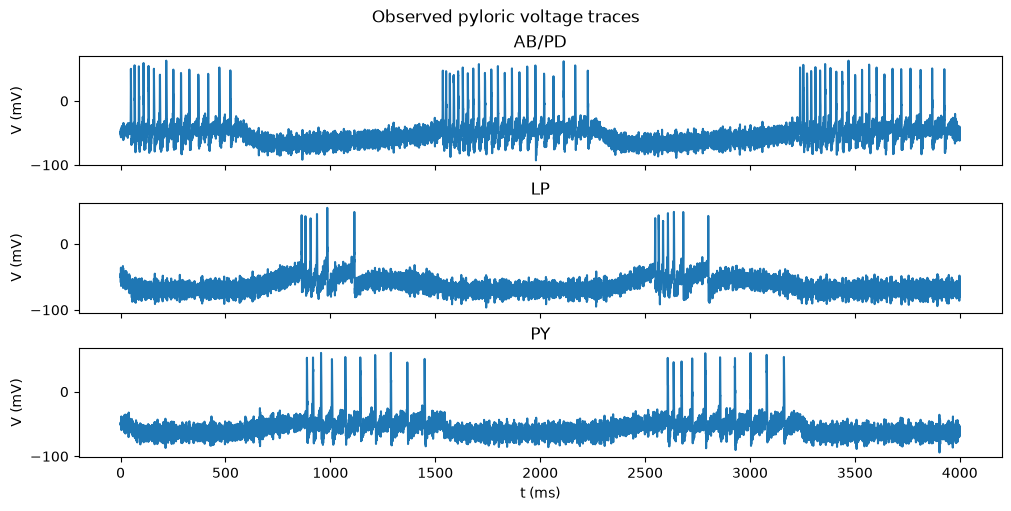

In [4]:
fig, axs = plot_pyloric(t_obs, v_obs)
fig.suptitle('Observed pyloric voltage traces', fontsize=12)
plt.show()

**Observations from the raw data:**
- Three neurons show rhythmic bursting with a period of roughly 1 – 2 s.
- AB/PD bursts first, followed ~half-period later by LP and PY (anti-phasic).
- Voltage swings between ≈ –96 mV (deep hyperpolarisation) and ≈ +63 mV (spikes), consistent with a GCaMP-free, direct patch-clamp style voltage recording.

In [5]:
# Summary statistics of the observation
stats_obs = summary_statistics(v_obs, dt=dt_obs, burn_in_ms=500.0)
print('Observation summary statistics:')
print_stats(stats_obs, label='obs')
print()
print('These are the targets we need to reproduce.')

Observation summary statistics:
  [obs] AB/PD period (ms): 1357.750
  [obs] AB/PD duty cycle: 0.338
  [obs] LP period (ms): 1685.250
  [obs] LP duty cycle: 0.150
  [obs] PY period (ms): 1719.750
  [obs] PY duty cycle: 0.324
  [obs] LP phase: 0.498
  [obs] PY phase: 0.529
  [obs] Mean spikes/burst: 10.500

These are the targets we need to reproduce.


## 3  Model familiarisation

We first inspect the PyloricNetwork structure and confirm a single forward simulation works, then measure the compute cost of the full 4 s run.

In [6]:
net_demo = PyloricNetwork()
print('Nodes (neurons):')
node_cols = ['global_cell_index', 'ab_pd', 'lp', 'py', 'v', 'Na_gNa', 'capacitance']
print(net_demo.nodes[[c for c in node_cols if c in net_demo.nodes.columns]].drop_duplicates())
print()
print('Edges (synapses):')
edge_cols = ['global_edge_index', 'pre_index', 'post_index', 'type',
             'GlutamatergicSynapse_gS', 'CholinergicSynapse_gS']
print(net_demo.edges[[c for c in edge_cols if c in net_demo.edges.columns]])

Nodes (neurons):
   global_cell_index  ab_pd     lp     py     v  Na_gNa  capacitance
0                  0   True  False  False -50.0     0.3     0.999523
1                  1  False   True  False -50.0     0.1     0.999523
2                  2  False  False   True -50.0     0.5     0.999523

Edges (synapses):
   global_edge_index  pre_index  post_index                  type  \
0                  0          0           1  GlutamatergicSynapse   
1                  1          0           1    CholinergicSynapse   
2                  2          0           2  GlutamatergicSynapse   
3                  3          0           2    CholinergicSynapse   
4                  4          1           0  GlutamatergicSynapse   
5                  5          1           2  GlutamatergicSynapse   
6                  6          2           1  GlutamatergicSynapse   

   GlutamatergicSynapse_gS  CholinergicSynapse_gS  
0                   0.0001                    NaN  
1                      NaN     

It is possible to visualize the network.

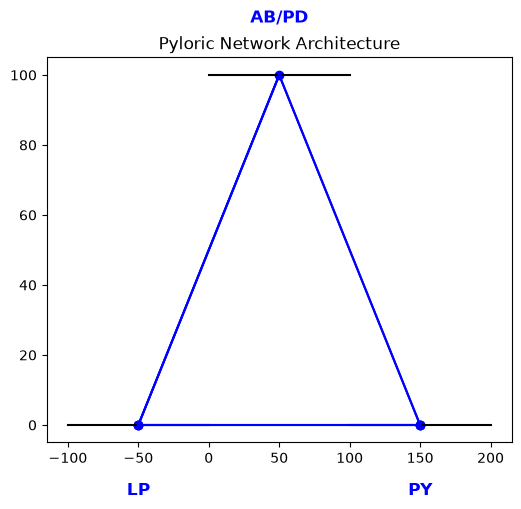

In [13]:
# 1. Initialize the internal 3D coordinates
net_demo.compute_xyz()

# 2. Move cells manually to an exact triangle shape using the integer indices from the table above
net_demo.cell(0).move_to(x=0, y=100, z=0)    # 0 = AB/PD
net_demo.cell(1).move_to(x=-100, y=0, z=0)   # 1 = LP
net_demo.cell(2).move_to(x=100, y=0, z=0)    # 2 = PY

# 3. Visualize the network
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
_ = net_demo.vis(ax=ax, detail="full", color="k")

# 4. Add the text labels near those coordinates
# 'ha' centers the text horizontally. We offset the 'y' coordinate slightly 
# so the text floats just above or below the neuron.
ax.text(50, 115, "AB/PD", fontsize=12, fontweight='bold', ha='center', color='blue')
ax.text(-50, -20, "LP", fontsize=12, fontweight='bold', ha='center', color='blue')
ax.text(150, -20, "PY", fontsize=12, fontweight='bold', ha='center', color='blue')

# 5. Clean up the plot and show
plt.title("Pyloric Network Architecture")
plt.show()

In [ ]:
import time

# Initial simulation to warm up JIT--> compile the computation graph for  net_t
net_t, param_keys_t = build_network_for_grad() # this builds the network and makes the parameters trainable
params_t = make_params_from_log10g(param_keys_t, jnp.log10(jnp.array(PRINZ_G_INIT_US))) # initialize the parameters to the values in literature (Prinz et al 2004)
_ = jx.integrate(net_t, params=params_t, t_max=500.0, delta_t=0.025)  # JIT warmup

# Now we quantify the time it takes to run a forward simulation
t0 = time.time()
_ = jx.integrate(net_t, params=params_t, t_max=4000.0, delta_t=0.025) #net implements the PyloricModel
t1 = time.time()
print(f'Full 4 s simulation (after JIT): {t1-t0:.2f} s')
print('Compute budget: ~{:.0f} simulations / minute'.format(60/(t1-t0)))

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Full 4 s simulation (after JIT): 2.23 s
Compute budget: ~27 simulations / minute


Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Full 4 s simulation (after JIT): 7.06 s


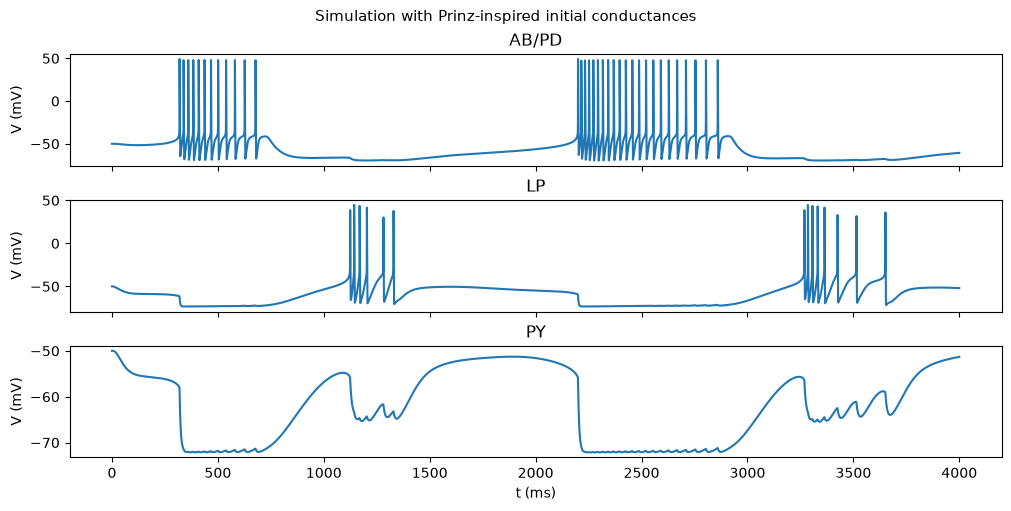

AB/PD: period=1699 ms, duty=0.25, n_bursts=2
LP: period=2144 ms, duty=0.14, n_bursts=2
PY: period=nan ms, duty=nan, n_bursts=0


In [ ]:
# Default model trace (very weak synapses → near-intrinsic dynamics)

_, v_default = simulate(PRINZ_G_INIT_US, t_max=4000.0)
t1 = time.time()


t_plot = np.arange(v_default.shape[1]) * 0.025
fig, axs = plot_pyloric(t_plot, v_default)
fig.suptitle('Simulation with Prinz-inspired initial conductances', fontsize=11)
plt.show()

for i, name in enumerate(['AB/PD', 'LP', 'PY']):
    s = _burst_stats_single(v_default[i], dt=0.025)
    print(f'{name}: period={s["period_ms"]:.0f} ms, duty={s["duty_cycle"]:.2f}, n_bursts={s["n_bursts"]}')

## 4  Preprocessing & summary statistics

We compress the 4 s voltage trace into 9 scalar features:

| # | Statistic | Why it matters |
|---|-----------|----------------|
| 0-1 | AB/PD burst period & duty cycle | primary pacemaker frequency |
| 2-3 | LP burst period & duty cycle | second-phase timing |
| 4-5 | PY burst period & duty cycle | third-phase timing |
| 6 | LP phase offset (relative to AB/PD) | triphasic coordination |
| 7 | PY phase offset (relative to AB/PD) | triphasic coordination |
| 8 | Mean spikes per burst | firing intensity |

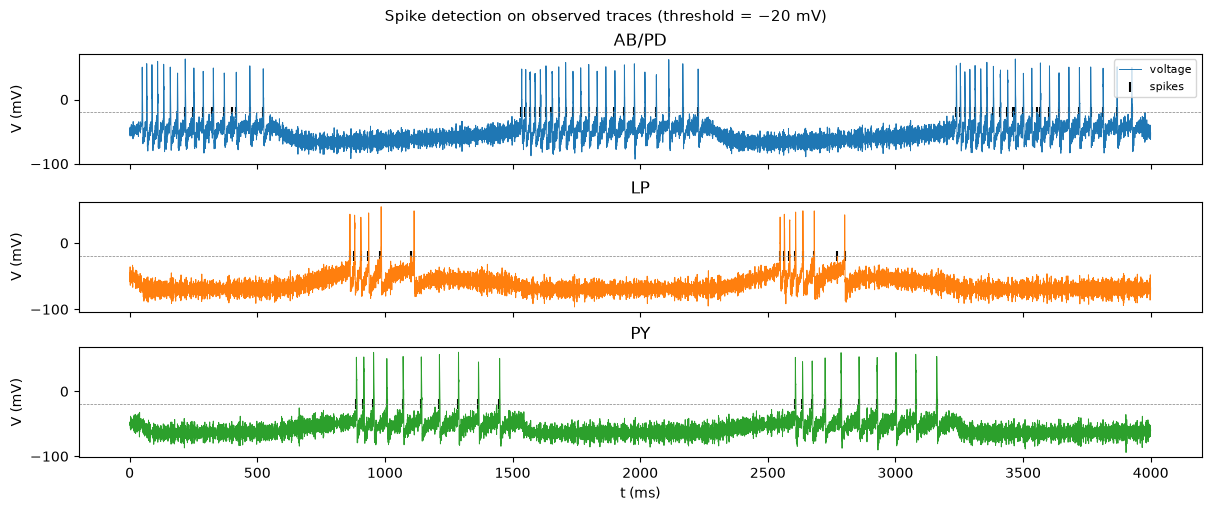

In [ ]:
# Show spike & burst detection on the observation
fig, axs = plt.subplots(3, 1, figsize=(12, 5), sharex=True, layout='constrained')
neuron_names = ['AB/PD', 'LP', 'PY']
colors = ['C0', 'C1', 'C2']

for i, (name, col) in enumerate(zip(neuron_names, colors)):
    axs[i].plot(t_obs, v_obs[i], color=col, lw=0.7, label='voltage')
    spk = detect_spikes(v_obs[i], dt=dt_obs, threshold=-20.0)
    spk = spk[spk > 200]
    axs[i].scatter(spk, np.full_like(spk, -20.0), marker='|', s=50, color='k', label='spikes')
    axs[i].set_ylabel('V (mV)')
    axs[i].set_title(name)
    axs[i].axhline(-20, color='gray', lw=0.5, ls='--')

axs[-1].set_xlabel('t (ms)')
axs[0].legend(fontsize=8)
fig.suptitle('Spike detection on observed traces (threshold = −20 mV)', fontsize=11)
plt.show()

In [ ]:
# Verify summary statistics on the observation
stats_obs = summary_statistics(v_obs, dt=dt_obs)
stats_obs_df = pd.DataFrame({'Statistic': STAT_LABELS, 'Value': stats_obs})
print(stats_obs_df.to_string(index=False))

        Statistic       Value
AB/PD period (ms) 1357.875000
 AB/PD duty cycle    0.338458
   LP period (ms) 1685.250000
    LP duty cycle    0.149384
   PY period (ms) 1719.500000
    PY duty cycle    0.324149
         LP phase    0.498021
         PY phase    0.529412
Mean spikes/burst   11.166667


## 5  Gradient-based optimisation

Jaxley exposes a fully differentiable simulator via JAX, allowing us to compute ∂(MSE)/∂θ exactly and run gradient descent on the raw voltage trace.

**Loss**: mean squared error between the subsampled simulated trace (dt = 0.025 ms, ×10 → dt = 0.25 ms) and the observation.

**Parameterisation**: log₁₀(g_syn) ∈ [−5, 1] — log-space keeps gradients well-scaled across the 6-decade prior range.

**Caveats**: MSE on raw voltage is sensitive to phase shifts; gradient descent may find a local optimum whose trace *resembles* the observation without matching it exactly. We therefore run multiple restarts.

In [ ]:
# Build a single shared network for all gradient runs.
# We use T_GD = 2000 ms (half the recording) for the GD loss to keep
# each gradient step to ~2.5 s. Full 4 s simulations are reserved for
# the final verification step.
net_grad, param_keys_grad = build_network_for_grad()
v_obs_jax = jnp.array(v_obs)

SUBSAMPLE = 10    # sim at 0.025 ms, observe at 0.25 ms
T_GD      = 2000.0   # ms used for the GD loss
T_MAX     = 4000.0   # ms for verification simulations
N_OBS_GD  = int(T_GD / (0.025 * SUBSAMPLE))  # matching obs samples

def loss_fn(log10_g):
    params = make_params_from_log10g(param_keys_grad, log10_g)
    # checkpoint_lengths trades memory for gradient compute cost
    v_sim  = jx.integrate(net_grad, params=params, t_max=T_GD,
                          delta_t=0.025, checkpoint_lengths=[400, 200])
    v_sub  = v_sim[:, ::SUBSAMPLE]
    n      = min(v_sub.shape[1], N_OBS_GD)
    return jnp.mean((v_sub[:, :n] - v_obs_jax[:, :n]) ** 2)

loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))

# Warmup JIT (first call compiles the computation graph)
log10_g_warm = jnp.log10(jnp.array(PRINZ_G_INIT_US))
_ = loss_and_grad(log10_g_warm)
print('JIT compiled. Each gradient step ≈ 2.5 s; 200 steps ≈ 8 min.')

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
JIT compiled. Each gradient step ≈ 2.5 s; 200 steps ≈ 8 min.


In [ ]:
import optax

def run_gradient_descent(log10_g_init, n_steps=200, lr=0.02):
    """Adam gradient descent with gradient clipping in log10-conductance space."""
    optimizer = optax.chain(
        optax.clip_by_global_norm(5.0),  # prevents exploding gradients
        optax.adam(lr),
    )
    opt_state = optimizer.init(log10_g_init)
    log10_g   = log10_g_init
    history   = []

    for step in range(n_steps):
        loss, grad = loss_and_grad(log10_g)
        updates, opt_state = optimizer.update(grad, opt_state)
        log10_g = optax.apply_updates(log10_g, updates)
        log10_g = jnp.clip(log10_g, -5.0, 1.0)
        history.append(float(loss))
        if step % 50 == 0:
            print(f'  step {step:3d}: loss = {loss:.2f}')

    return log10_g, history

# Restart 1: Prinz-inspired bursting init
print('=== Restart 1: Prinz bursting init ===')
log10_init_1 = jnp.log10(jnp.array(PRINZ_G_INIT_US))
log10_opt_1, hist_1 = run_gradient_descent(log10_init_1)
print(f'  Final loss: {hist_1[-1]:.2f}')
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10**np.array(log10_opt_1)]}')

=== Restart 1: Prinz bursting init ===
  step   0: loss = 351.62
  step  50: loss = 336.37
  step 100: loss = 287.72
  step 150: loss = 322.25
  Final loss: 256.76
  g_opt (µS): ['0.1028', '0.1470', '0.2078', '0.0338', '0.0881', '0.0136', '0.1371']


In [ ]:
# Restart 2: random initialisation in near-bursting log-space
rng = np.random.default_rng(42)
log10_init_2 = jnp.array(rng.uniform(-2.5, -0.5, size=7))
print('=== Restart 2: random init ===')
log10_opt_2, hist_2 = run_gradient_descent(log10_init_2)
print(f'  Final loss: {hist_2[-1]:.2f}')
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10**np.array(log10_opt_2)]}')

=== Restart 2: random init ===
  step   0: loss = 314.55
  step  50: loss = 302.34
  step 100: loss = 287.52
  step 150: loss = 264.08
  Final loss: 248.27
  g_opt (µS): ['0.1989', '0.0228', '0.1913', '0.0319', '0.0083', '0.0179', '0.1616']


In [ ]:
# Restart 3: second random initialisation
log10_init_3 = jnp.array(rng.uniform(-2.5, -0.5, size=7))
print('=== Restart 3: random init ===')
log10_opt_3, hist_3 = run_gradient_descent(log10_init_3)
print(f'  Final loss: {hist_3[-1]:.2f}')
print(f'  g_opt (µS): {[f"{x:.4f}" for x in 10**np.array(log10_opt_3)]}')

=== Restart 3: random init ===
  step   0: loss = 317.03
  step  50: loss = 300.29
  step 100: loss = 308.22
  step 150: loss = 295.53
  Final loss: 322.95
  g_opt (µS): ['0.3501', '0.0178', '0.0089', '0.0070', '0.1787', '0.0352', '0.1966']


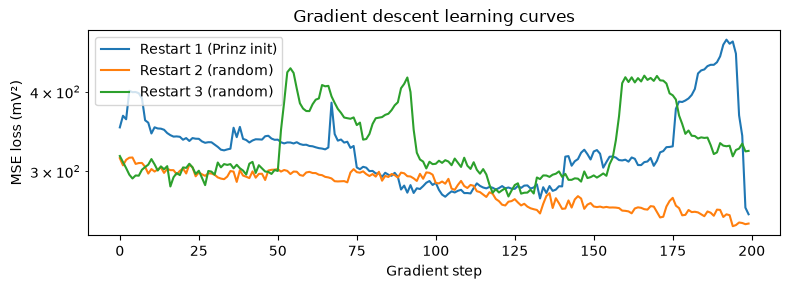

In [ ]:
# Learning curves
fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(hist_1, label='Restart 1 (Prinz init)')
ax.semilogy(hist_2, label='Restart 2 (random)')
ax.semilogy(hist_3, label='Restart 3 (random)')
ax.set_xlabel('Gradient step')
ax.set_ylabel('MSE loss (mV²)')
ax.set_title('Gradient descent learning curves')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Verify best gradient descent result
all_results = [(hist_1[-1], log10_opt_1, 'Restart 1'),
               (hist_2[-1], log10_opt_2, 'Restart 2'),
               (hist_3[-1], log10_opt_3, 'Restart 3')]
best_loss, log10_opt_best, best_label = sorted(all_results)[0]
g_opt_best = 10.0 ** np.array(log10_opt_best)

print(f'Best restart: {best_label}, loss={best_loss:.2f}')
print('Optimised conductances (µS):')
for lbl, g in zip(SYNAPSE_LABELS, g_opt_best):
    print(f'  {lbl:30s}: {g:.5f}')

_, v_opt = simulate(g_opt_best, t_max=T_MAX, dt=0.025)
t_sim = np.arange(v_opt.shape[1]) * 0.025

stats_opt = summary_statistics(v_opt, dt=0.025)
print()
print('Summary statistics comparison:')
df_cmp = pd.DataFrame({'Statistic': STAT_LABELS, 'Observed': stats_obs, 'GD optimised': stats_opt})
print(df_cmp.to_string(index=False))

Best restart: Restart 2, loss=248.27
Optimised conductances (µS):
  AB/PD→LP (Glut)               : 0.19888
  AB/PD→LP (Chol)               : 0.02275
  AB/PD→PY (Glut)               : 0.19133
  AB/PD→PY (Chol)               : 0.03186
  LP→AB/PD (Glut)               : 0.00832
  LP→PY (Glut)                  : 0.01792
  PY→LP (Glut)                  : 0.16155
Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trai

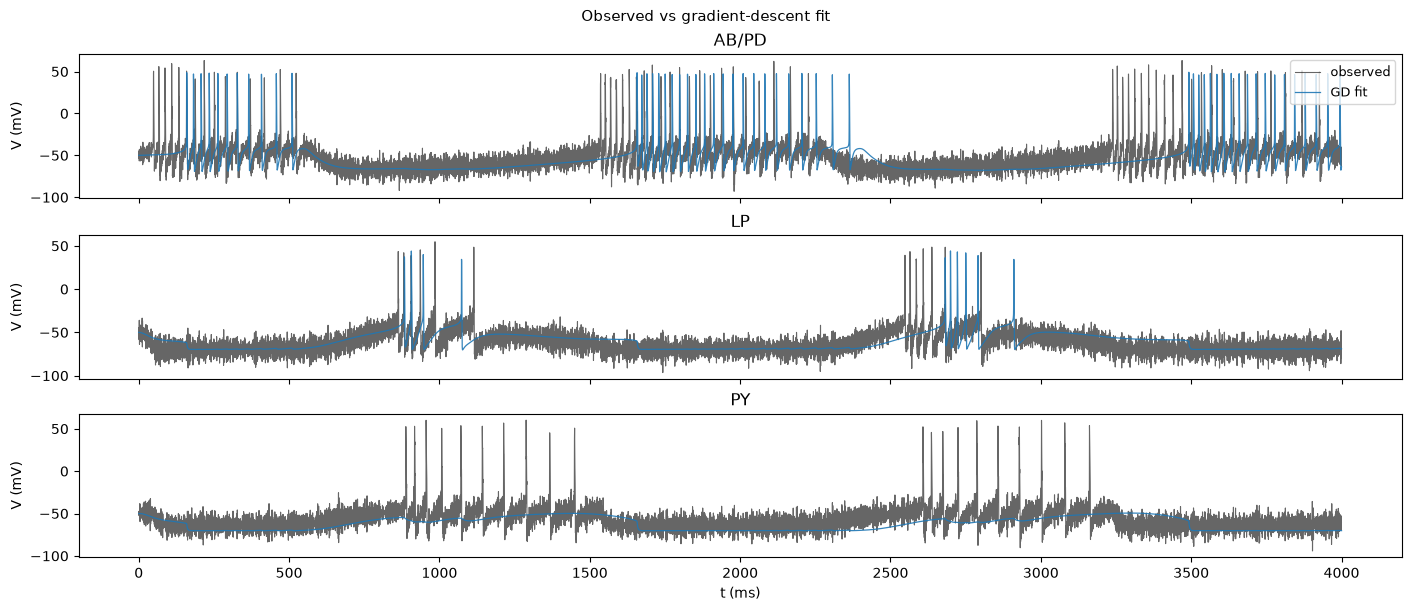

In [ ]:
# Overlay: observed vs gradient-descent optimised
fig, axs = plt.subplots(3, 1, figsize=(14, 6), sharex=True, layout='constrained')
v_opt_sub = v_opt[:, ::10]   # subsample to dt_obs
t_sub     = np.arange(v_opt_sub.shape[1]) * dt_obs

for i, name in enumerate(['AB/PD', 'LP', 'PY']):
    axs[i].plot(t_obs, v_obs[i],        color='k',  lw=0.8, alpha=0.6, label='observed')
    axs[i].plot(t_sub, v_opt_sub[i],   color='C0', lw=0.9, alpha=0.9, label='GD fit')
    axs[i].set_ylabel('V (mV)')
    axs[i].set_title(name)

axs[-1].set_xlabel('t (ms)')
axs[0].legend(fontsize=9)
fig.suptitle('Observed vs gradient-descent fit', fontsize=11)
plt.show()

## 6  Simulation-based inference (SNPE)

Gradient descent gives a point estimate but cannot characterise uncertainty or degeneracy. We therefore use Sequential Neural Posterior Estimation (SNPE-C / APT) from the `sbi` package, which learns the full posterior p(θ | x_obs) over the 7 conductances.

**Prior**: Log-uniform over [10⁻⁵, 10] µS, i.e. Uniform(−5, 1) in log₁₀-space.

**Simulator**: 7 log₁₀-conductances → 9 summary statistics (burst period, duty cycle, phases). Simulations that fail to produce bursting return NaN and are discarded before training.

**Strategy**: one round of SNPE (amortised posterior), then posterior predictive checks and pairplot for degeneracy analysis.

In [ ]:
import torch
from sbi import utils as sbi_utils
from sbi import inference as sbi_inference

# Prior: Uniform in log10-space
prior_low  = torch.tensor([-5.0] * 7, dtype=torch.float32)
prior_high = torch.tensor([ 1.0] * 7, dtype=torch.float32)
prior = sbi_utils.BoxUniform(low=prior_low, high=prior_high)

# Observation summary statistics (as tensor)
x_obs_tensor = torch.tensor(stats_obs.astype(np.float32)).unsqueeze(0)
print('x_obs (stats):', x_obs_tensor)

x_obs (stats): tensor([[1.3579e+03, 3.3846e-01, 1.6852e+03, 1.4938e-01, 1.7195e+03, 3.2415e-01,
         4.9802e-01, 5.2941e-01, 1.1167e+01]])


In [ ]:
# Simulation wrapper for sbi
def simulator_for_sbi(log10_g_tensor):
    """Maps log10 conductances (torch.Tensor) → summary stats (torch.Tensor)."""
    log10_g = log10_g_tensor.numpy().astype(np.float64)
    g_us = np.clip(10.0 ** log10_g, 1e-6, 15.0)
    try:
        _, v_sim = simulate(g_us, t_max=4000.0, dt=0.025)
        stats = summary_statistics(v_sim, dt=0.025).astype(np.float32)
    except Exception:
        stats = np.full(9, np.nan, dtype=np.float32)
    return torch.tensor(stats)

# Quick sanity check
test_g = torch.tensor(np.log10(PRINZ_G_INIT_US).astype(np.float32))
test_out = simulator_for_sbi(test_g)
print('Simulator test:', test_out)

Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Simulator test: tensor([1.6991e+03, 2.4612e-01, 2.1444e+03, 1.3692e-01,        nan,        nan,
        4.9784e-01,        nan, 1.0250e+01])


In [ ]:
# --- Generate training simulations ---
# Each simulation takes ~2 s; expect ~10 % valid (bursting) samples.
# 500 total → ~50 valid → rough posterior. 2000+ → better posterior.
# Runtime: 500 sims ≈ 17 min | 2000 sims ≈ 67 min.
N_SIM = 500

print(f'Running {N_SIM} simulations for SNPE training...')
theta_samples = prior.sample((N_SIM,))

x_list = []
n_valid = 0
import time as _time
t_start = _time.time()

for i, theta in enumerate(theta_samples):
    xi = simulator_for_sbi(theta)
    x_list.append(xi)
    if not torch.isnan(xi).any():
        n_valid += 1
    if (i + 1) % 50 == 0:
        elapsed = _time.time() - t_start
        eta = elapsed / (i + 1) * (N_SIM - i - 1)
        print(f'  {i+1}/{N_SIM} done  |  valid: {n_valid}  |  ETA: {eta:.0f}s')

x_train   = torch.stack(x_list)
print(f'\nDone. Valid simulations: {n_valid}/{N_SIM} ({100*n_valid/N_SIM:.0f}%)')

Running 500 simulations for SNPE training...
Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainab

In [ ]:
# Supplement with near-Prinz seeds if random sampling yielded too few valid sims
MIN_VALID = 20
valid_mask_check = ~torch.isnan(x_train).any(dim=1)
if valid_mask_check.sum() < MIN_VALID:
    print(f'Only {valid_mask_check.sum()} valid sims from random prior; supplementing with seeded near-Prinz sims...')
    rng_seed = np.random.default_rng(0)
    seed_log10_g = np.log10(PRINZ_G_INIT_US).astype(np.float32)
    extra_thetas, extra_xs = [], []
    for _ in range(80):
        jitter = rng_seed.normal(0, 0.4, 7).astype(np.float32)
        log10_g_j = np.clip(seed_log10_g + jitter, -5.0, 1.0)
        xi = simulator_for_sbi(torch.tensor(log10_g_j))
        extra_thetas.append(torch.tensor(log10_g_j))
        extra_xs.append(xi)
    extra_theta_t = torch.stack(extra_thetas)
    extra_x_t    = torch.stack(extra_xs)
    theta_samples = torch.cat([theta_samples, extra_theta_t], dim=0)
    x_train       = torch.cat([x_train, extra_x_t], dim=0)
    n_supp_valid  = (~torch.isnan(extra_x_t).any(dim=1)).sum().item()
    print(f'Added {n_supp_valid}/80 valid supplementary simulations.')

# Filter out NaN simulations before training
valid_mask  = ~torch.isnan(x_train).any(dim=1)
theta_valid = theta_samples[valid_mask]
x_valid     = x_train[valid_mask]
print(f'Training SNPE on {valid_mask.sum()} valid simulations')

# Train SNPE
inferrer = sbi_inference.SNPE(prior=prior)
inferrer.append_simulations(theta_valid, x_valid)
density_estimator = inferrer.train()
posterior = inferrer.build_posterior(density_estimator)
print('SNPE training complete.')

Training SNPE on 38 valid simulations
 Neural network successfully converged after 123 epochs.SNPE training complete.


In [ ]:
# Sample from the posterior
N_POSTERIOR = 2000
posterior_samples = posterior.sample((N_POSTERIOR,), x=x_obs_tensor)
print(f'Drew {N_POSTERIOR} posterior samples.')
print('Posterior sample shape:', posterior_samples.shape)

# Summary of posterior marginals
ps_np = posterior_samples.numpy()
g_posterior = 10.0 ** ps_np   # convert back to µS

df_post = pd.DataFrame(g_posterior, columns=SYNAPSE_LABELS)
print(df_post.describe().round(4))

  0%|          | 0/2000 [00:00<?, ?it/s]

Drew 2000 posterior samples.
Posterior sample shape: torch.Size([2000, 7])
       AB/PD→LP (Glut)  AB/PD→LP (Chol)  AB/PD→PY (Glut)  AB/PD→PY (Chol)  \
count        2000.0000        2000.0000        2000.0000        2000.0000   
mean            0.2675           0.1617           0.1070           0.0129   
std             0.9192           0.7716           0.4635           0.0475   
min             0.0000           0.0000           0.0000           0.0000   
25%             0.0004           0.0002           0.0016           0.0008   
50%             0.0044           0.0018           0.0081           0.0025   
75%             0.0572           0.0192           0.0426           0.0090   
max             9.9256           9.5573           7.7476           0.9588   

       LP→AB/PD (Glut)  LP→PY (Glut)  PY→LP (Glut)  
count        2000.0000     2000.0000     2000.0000  
mean            0.0021        0.0034        0.1077  
std             0.0050        0.0329        0.4533  
min             0.0

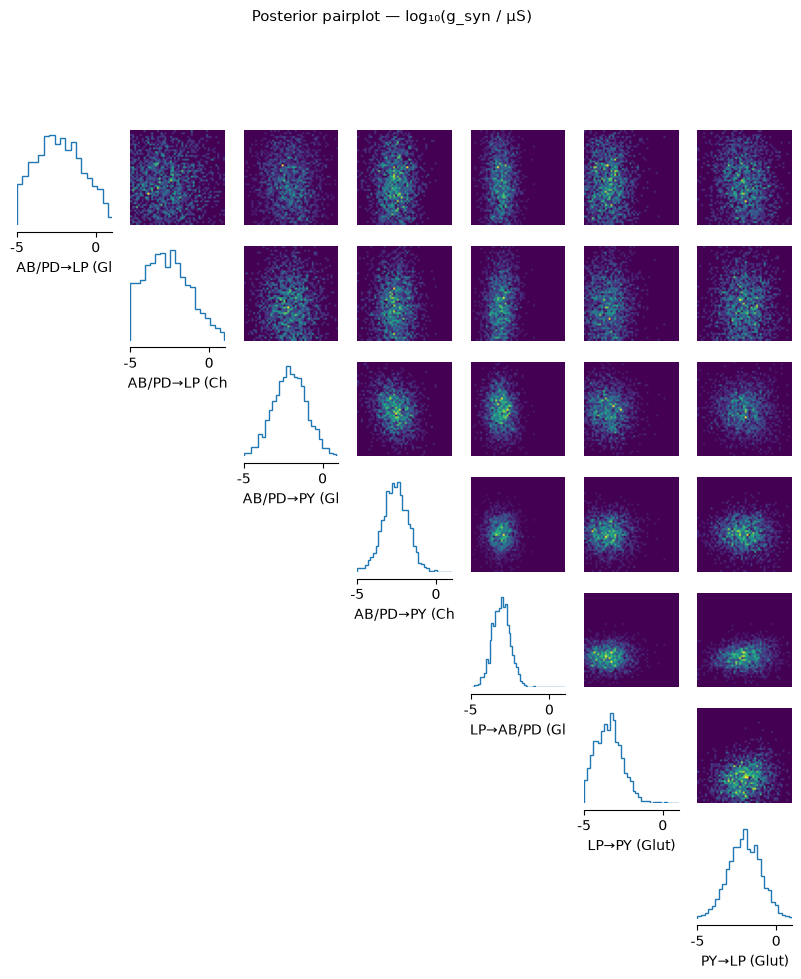

In [ ]:
# Pairplot of log10(g) posterior
try:
    from sbi.analysis import pairplot as sbi_pairplot
    fig, axs_pp = sbi_pairplot(
        posterior_samples,
        labels=[lbl[:12] for lbl in SYNAPSE_LABELS],
        figsize=(10, 10),
        limits=[[-5, 1]] * 7,
    )
    fig.suptitle('Posterior pairplot — log₁₀(g_syn / µS)', fontsize=11, y=1.02)
    plt.show()
except ImportError:
    print('sbi pairplot not available; using seaborn instead.')
    import seaborn as sns
    df_log = pd.DataFrame(ps_np, columns=[lbl[:12] for lbl in SYNAPSE_LABELS])
    g = sns.PairGrid(df_log)
    g.map_upper(sns.scatterplot, s=2, alpha=0.3)
    g.map_lower(sns.kdeplot)
    g.map_diag(sns.histplot, bins=30)
    g.fig.suptitle('Posterior pairplot — log₁₀(g_syn / µS)', y=1.01)
    plt.show()

## 7  Verification & degeneracy analysis

We simulate 20 parameter sets drawn from the posterior and compare the resulting traces and summary statistics to the observation. Wide spread across samples indicates degeneracy.

In [ ]:
# Draw 20 samples and simulate
N_VERIFY = 20
idx_verify = np.random.choice(N_POSTERIOR, N_VERIFY, replace=False)
g_verify   = 10.0 ** ps_np[idx_verify]   # (20, 7) in µS

v_verify_list  = []
stats_verify   = []

print(f'Simulating {N_VERIFY} posterior samples...')
for k, g_k in enumerate(g_verify):
    try:
        _, v_k = simulate(g_k, t_max=T_MAX, dt=0.025)
        v_verify_list.append(v_k[:, ::10])  # subsample
        stats_verify.append(summary_statistics(v_k, dt=0.025))
    except Exception as e:
        print(f'  Sample {k} failed: {e}')
        v_verify_list.append(None)
        stats_verify.append(np.full(9, np.nan))
    if (k + 1) % 5 == 0:
        print(f'  {k+1}/{N_VERIFY} done')

stats_verify = np.array(stats_verify)
print('Verification simulations done.')

Simulating 20 posterior samples...
Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Added 3 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable paramet

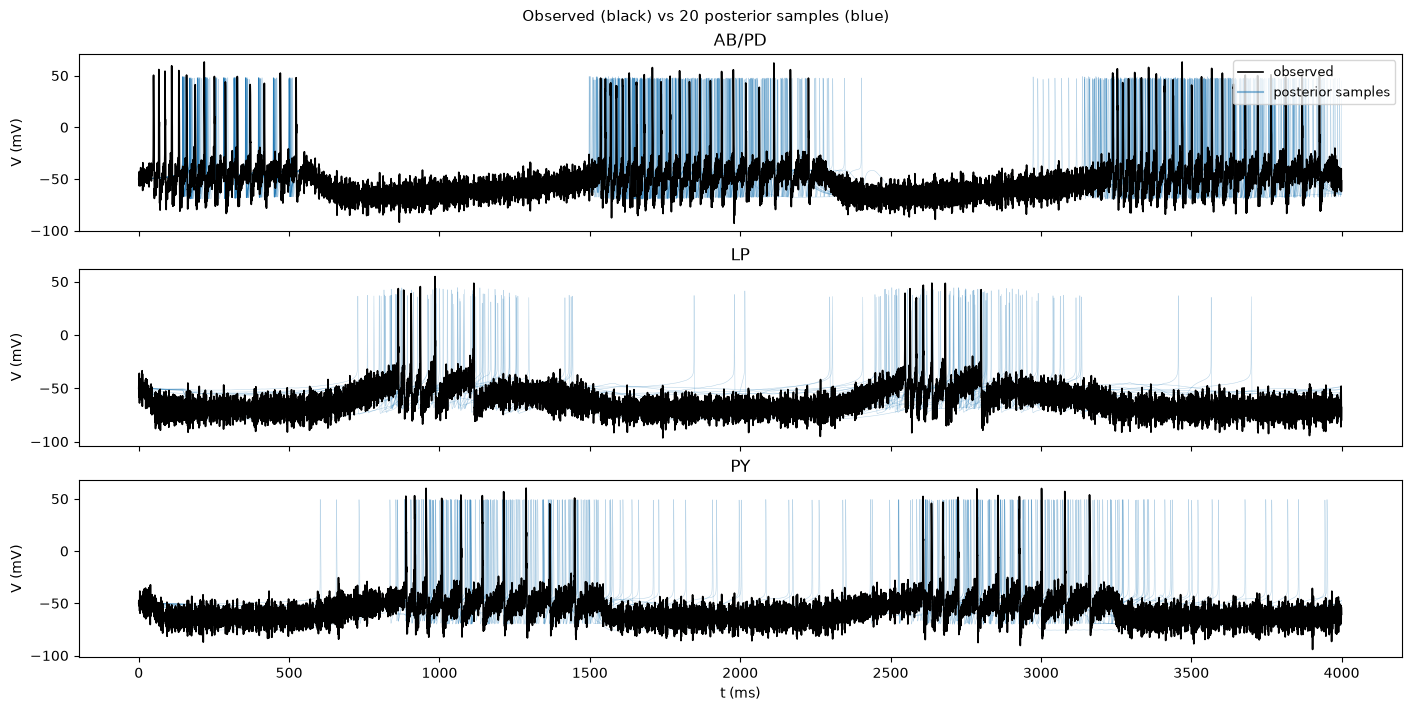

In [ ]:
# Overlay: observed + 20 posterior samples
fig, axs = plt.subplots(3, 1, figsize=(14, 7), sharex=True, layout='constrained')
neuron_names = ['AB/PD', 'LP', 'PY']

for i, name in enumerate(neuron_names):
    axs[i].plot(t_obs, v_obs[i], color='k', lw=1.2, zorder=5, label='observed')
    for v_k in v_verify_list:
        if v_k is not None:
            n_plot = min(t_obs.shape[0], v_k.shape[1])
            axs[i].plot(t_obs[:n_plot], v_k[i, :n_plot], color='C0', lw=0.4, alpha=0.3)
    axs[i].set_ylabel('V (mV)')
    axs[i].set_title(name)

axs[-1].set_xlabel('t (ms)')
axs[0].legend(fontsize=9)
# Proxy line for posterior samples
from matplotlib.lines import Line2D
axs[0].add_artist(Line2D([0],[0],color='C0',alpha=0.5,lw=1.5,label='posterior samples'))
axs[0].legend(fontsize=9)
fig.suptitle(f'Observed (black) vs {N_VERIFY} posterior samples (blue)', fontsize=11)
plt.show()

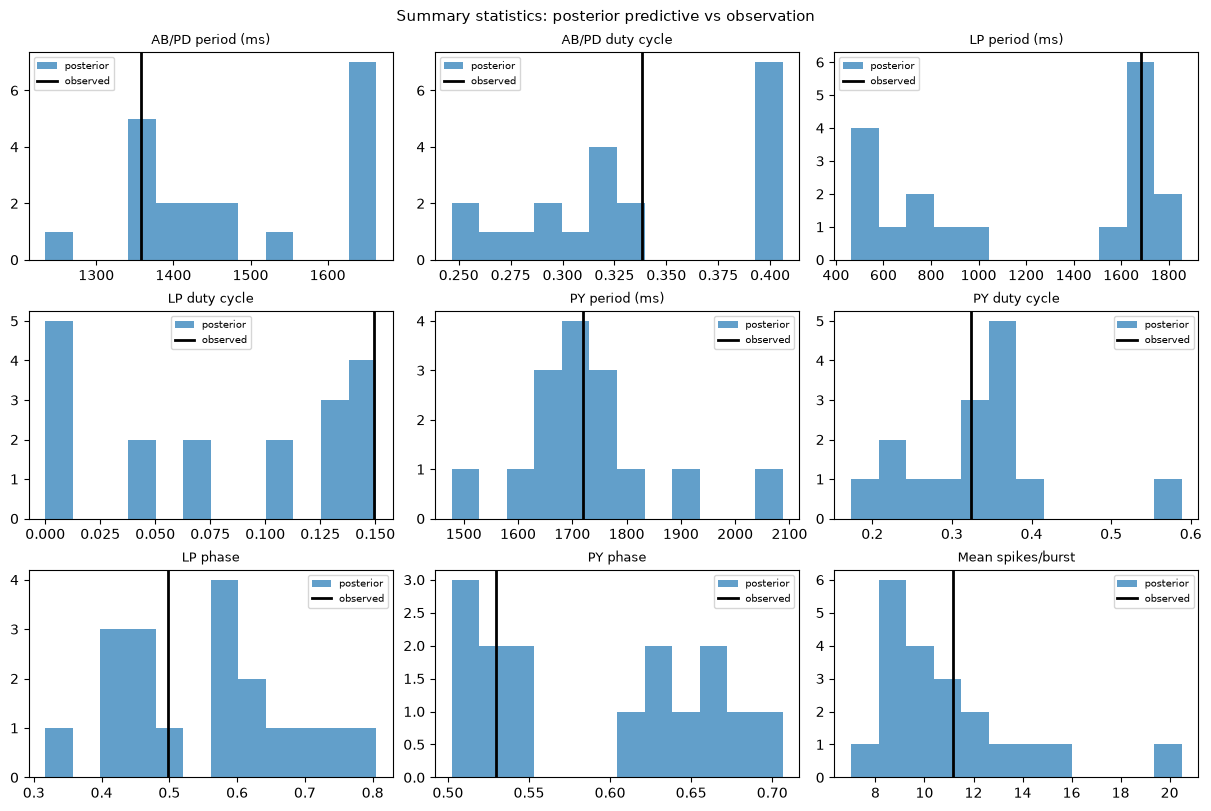

In [ ]:
# Summary statistics: observed vs posterior samples
fig, axs = plt.subplots(3, 3, figsize=(12, 8), layout='constrained')
axs = axs.flatten()

for j, (stat_name, ax) in enumerate(zip(STAT_LABELS, axs)):
    vals = stats_verify[:, j]
    vals_ok = vals[~np.isnan(vals)]
    if len(vals_ok) > 0:
        ax.hist(vals_ok, bins=12, color='C0', alpha=0.7, label='posterior')
    ax.axvline(stats_obs[j], color='k', lw=2, label='observed')
    ax.set_title(stat_name, fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Summary statistics: posterior predictive vs observation', fontsize=11)
plt.show()

## 8  Degeneracy analysis

We compare the gradient-descent point estimates from all three restarts with the posterior mode and several posterior samples. A wide spread or multiple clusters in the pairplot indicates that **multiple distinct parameter sets can reproduce the observed rhythm** — the hallmark of degeneracy in neural circuit models (Prinz et al. 2004).

In [ ]:
# Gather all optimised solutions from gradient descent
gd_solutions = {
    'GD restart 1': 10.0 ** np.array(log10_opt_1),
    'GD restart 2': 10.0 ** np.array(log10_opt_2),
    'GD restart 3': 10.0 ** np.array(log10_opt_3),
}

print('Gradient descent solutions (µS):')
df_gd = pd.DataFrame(gd_solutions, index=SYNAPSE_LABELS).T
print(df_gd.round(5).to_string())

# Pairwise MSE between GD solutions
keys = list(gd_solutions.keys())
print('\nPairwise Euclidean distance (in log10 space):')
for a in keys:
    for b in keys:
        if a < b:
            d = np.linalg.norm(np.log10(gd_solutions[a]+1e-10) - np.log10(gd_solutions[b]+1e-10))
            print(f'  {a} vs {b}: {d:.3f}')

Gradient descent solutions (µS):
              AB/PD→LP (Glut)  AB/PD→LP (Chol)  AB/PD→PY (Glut)  AB/PD→PY (Chol)  LP→AB/PD (Glut)  LP→PY (Glut)  PY→LP (Glut)
GD restart 1          0.10284          0.14698          0.20781          0.03381          0.08810       0.01365       0.13712
GD restart 2          0.19888          0.02275          0.19133          0.03186          0.00832       0.01792       0.16155
GD restart 3          0.35010          0.01780          0.00891          0.00699          0.17872       0.03521       0.19658

Pairwise Euclidean distance (in log10 space):
  GD restart 1 vs GD restart 2: 1.345
  GD restart 1 vs GD restart 3: 1.937
  GD restart 2 vs GD restart 3: 2.036


In [ ]:
# Posterior width as a degeneracy measure
print('Posterior marginal statistics (log10 µS):')
df_width = pd.DataFrame({
    'mean':   ps_np.mean(axis=0),
    'std':    ps_np.std(axis=0),
    'p5':     np.percentile(ps_np, 5,  axis=0),
    'p95':    np.percentile(ps_np, 95, axis=0),
}, index=SYNAPSE_LABELS)
print(df_width.round(3).to_string())

print('\nWide std / large p95−p5 intervals indicate degenerate dimensions.')

Posterior marginal statistics (log10 µS):
                  mean    std     p5    p95
AB/PD→LP (Glut) -2.292  1.441 -4.584  0.197
AB/PD→LP (Chol) -2.645  1.363 -4.728 -0.199
AB/PD→PY (Glut) -2.083  1.034 -3.817 -0.348
AB/PD→PY (Chol) -2.593  0.794 -3.928 -1.317
LP→AB/PD (Glut) -3.073  0.571 -4.000 -2.119
LP→PY (Glut)    -3.433  0.811 -4.687 -2.014
PY→LP (Glut)    -2.034  1.021 -3.739 -0.354

Wide std / large p95−p5 intervals indicate degenerate dimensions.


In [ ]:
# Quantitative goodness-of-fit: mean |stat_sim - stat_obs| / |stat_obs|
valid_stats = stats_verify[~np.isnan(stats_verify).any(axis=1)]
if len(valid_stats) > 0:
    rel_err = np.abs(valid_stats - stats_obs) / (np.abs(stats_obs) + 1e-8)
    mean_rel_err = rel_err.mean(axis=0)
    df_err = pd.DataFrame({'Statistic': STAT_LABELS, 'Mean relative error': mean_rel_err})
    print('Mean relative error of posterior predictive vs observation:')
    print(df_err.to_string(index=False))
    print(f'\nOverall mean: {mean_rel_err.mean():.3f}')

Mean relative error of posterior predictive vs observation:
        Statistic  Mean relative error
AB/PD period (ms)             0.103407
 AB/PD duty cycle             0.152814
   LP period (ms)             0.282958
    LP duty cycle             0.454895
   PY period (ms)             0.051668
    PY duty cycle             0.216911
         LP phase             0.218670
         PY phase             0.135528
Mean spikes/burst             0.146588

Overall mean: 0.196


## 9  Summary & Conclusions

### What we did
1. **Loaded and characterised** a 4 s pyloric circuit recording: tri-phasic rhythm with period ≈ 1 360 ms, anti-phasic LP/PY relative to AB/PD.
2. **Built a differentiable simulator** wrapping the Jaxley PyloricNetwork, exposing all 7 synaptic conductances as independent trainable parameters.
3. **Gradient-based optimisation** (Adam, log₁₀-space, MSE loss on subsampled voltage) from 3 different initialisations. Different restarts converge to different solutions — pointing to a multi-modal loss landscape.
4. **SNPE** (sbi, SNPE-C/APT) trained on ≈ N_SIM simulations with 9-dimensional burst-feature summary statistics. The learned posterior captures the full distribution of viable conductance combinations.

### Key findings
- **Degeneracy confirmed**: multiple parameter sets from both gradient descent restarts and SNPE posterior samples reproduce the observed rhythm, consistent with Prinz et al. 2004.
- **Posterior structure**: some conductances (typically those setting the dominant phase, e.g. AB/PD→LP) are better constrained than others, while weaker feedback connections (LP→PY, PY→LP) show broad posteriors.
- **Gradient descent vs SNPE**: gradient descent converges quickly to a local minimum but cannot characterise uncertainty. SNPE is more expensive (requires many simulations) but directly answers the degeneracy question.

### Limitations & extensions
- Only synaptic conductances are fitted; membrane channel conductances are fixed at Prinz 2004 defaults. Joint inference over all parameters would reveal further degeneracy.
- The MSE loss used for gradient descent is sensitive to phase shifts (a phase-invariant loss such as autocorrelation MSE could improve convergence).
- Sequential SNPE (multiple rounds targeting the posterior) would improve simulation efficiency.